In [1]:
"""
Streamlined Roof Texture Classification Training Script
Clean, efficient implementation with minimal redundancy - LIBPNG WARNING COMPLETELY SUPPRESSED
"""

import os
import pickle
import warnings
import sys
import subprocess
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import cpu_count

# NUCLEAR OPTION: Complete system-level warning suppression
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'
os.environ['OPENCV_OPENCL_DEVICE'] = 'disabled'
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '0'
os.environ['OPENCV_IO_ENABLE_JASPER'] = '0'

# Redirect stderr at the file descriptor level (lowest level possible)
import os
import sys

# Save original stderr file descriptor
original_stderr_fd = os.dup(2)

def silence_stderr():
    """Redirect stderr to null at the file descriptor level"""
    null_fd = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null_fd, 2)
    os.close(null_fd)

def restore_stderr():
    """Restore original stderr"""
    os.dup2(original_stderr_fd, 2)

# Apply maximum Python-level warning suppression
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
for category in [UserWarning, DeprecationWarning, RuntimeWarning, FutureWarning, Warning]:
    warnings.filterwarnings("ignore", category=category)

# Specific libpng warning patterns
libpng_patterns = [".*iCCP.*", ".*libpng.*", ".*sRGB.*", ".*profile.*", ".*PNG.*", ".*color.*"]
for pattern in libpng_patterns:
    warnings.filterwarnings("ignore", message=pattern)

# Comprehensive logging suppression
import logging
logging.disable(logging.CRITICAL)
for logger_name in ['PIL', 'PIL.PngImagePlugin', 'PIL.Image', 'matplotlib', 'cv2']:
    logging.getLogger(logger_name).setLevel(logging.CRITICAL)
    logging.getLogger(logger_name).disabled = True

# Context manager that silences everything
import contextlib

@contextlib.contextmanager
def nuclear_silence():
    """Ultimate silence - redirects stderr at file descriptor level"""
    silence_stderr()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            yield
        finally:
            restore_stderr()

# Import libraries with maximum suppression
with nuclear_silence():
    import PIL.Image
    PIL.Image.warnings.simplefilter('ignore')
    from PIL import Image
    import cv2
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader as TorchDataLoader, Dataset
    from torchvision import models, transforms
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from sklearn.model_selection import train_test_split
    from sklearn.utils.class_weight import compute_class_weight

# Additional suppression for OpenCV warnings
os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'


class Config:
    """Configuration class for training parameters"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 16
    NUM_EPOCHS = 150
    LEARNING_RATE = 0.001
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 5
    MIN_CONTOUR_AREA = 100
    MODEL_SAVE_PATH = "models/roof_texture_model.pth"


def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)


def get_device():
    """Get available device"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        print(f"Using GPU: {torch.cuda.get_device_name()}")
    return device


class RoofDataLoader:
    """Handles data loading and preprocessing"""

    def __init__(self, base_path):
        self.original_dir = f"{base_path}/patch"
        self.binary_dir = f"{base_path}/patch-binary"
        self.color_dir = f"{base_path}/patch-texture"
        self.cache_dir = f"{base_path}/cache"
        os.makedirs(self.cache_dir, exist_ok=True)

    def load_file_paths(self):
        """Load file paths with caching"""
        cache_file = os.path.join(self.cache_dir, 'file_paths.pkl')

        if os.path.exists(cache_file):
            print("Loading paths from cache...")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)

        print("Scanning directories...")
        filenames = sorted(os.listdir(self.original_dir))

        def check_files(filename):
            paths = [
                os.path.join(self.original_dir, filename),
                os.path.join(self.binary_dir, filename),
                os.path.join(self.color_dir, filename)
            ]
            return paths if all(os.path.exists(p) for p in paths) else None

        with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
            results = list(tqdm(
                executor.map(check_files, filenames),
                total=len(filenames),
                desc="Checking files"
            ))

        valid_paths = [r for r in results if r is not None]
        paths = list(zip(*valid_paths)) if valid_paths else ([], [], [])

        with open(cache_file, 'wb') as f:
            pickle.dump(paths, f)

        return paths


def get_label_from_color(color_patch, tolerance=15):
    """Extract label from color-coded patch"""
    colors = {
        "smooth": np.array([83, 217, 56]),
        "average": np.array([252, 240, 3]),
        "rough": np.array([255, 0, 0])
    }

    pixels = color_patch.reshape(-1, 3)
    counts = {}

    for label, color in colors.items():
        distances = np.abs(pixels - color).max(axis=1)
        counts[label] = np.sum(distances <= tolerance)

    # Return label with highest count
    return max(counts, key=counts.get) if max(counts.values()) > 50 else None


def process_image(args):
    """Process a single image to extract patches and labels"""
    img_path, binary_path, color_path, min_area, target_size = args

    try:
        # Load images with NUCLEAR warning suppression
        with nuclear_silence():
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
            color = cv2.imread(color_path)
            color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

        patches = []
        labels = []

        if valid_contours:
            for contour in valid_contours:
                x, y, w, h = cv2.boundingRect(contour)

                # Add padding
                padding = 10
                x = max(0, x - padding)
                y = max(0, y - padding)
                w = min(img.shape[1] - x, w + 2 * padding)
                h = min(img.shape[0] - y, h + 2 * padding)

                if w < 20 or h < 20:
                    continue

                # Extract and resize patches
                img_patch = cv2.resize(img[y:y+h, x:x+w], target_size)
                color_patch = cv2.resize(color[y:y+h, x:x+w], target_size)

                label = get_label_from_color(color_patch)

                if label is None:
                    continue  # Skip if no valid label

                patches.append(img_patch)
                labels.append(label)
        else:
            # Use full image if no contours
            img_patch = cv2.resize(img, target_size)
            color_patch = cv2.resize(color, target_size)
            label = get_label_from_color(color_patch)

            if label is not None:
                patches.append(img_patch)
                labels.append(label)

        return patches, labels

    except Exception as e:
        print(f"Error processing image: {e}")
        return [], []


def extract_patches(image_paths, binary_paths, color_paths, config):
    """Extract patches from all images"""
    cache_file = os.path.join(config.BASE_PATH, 'cache', 'patches_no_contour_removed.pkl')

    if os.path.exists(cache_file):
        print("Loading patches from cache...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    print("Extracting patches...")
    args_list = [
        (image_paths[i], binary_paths[i], color_paths[i],
         config.MIN_CONTOUR_AREA, (config.IMAGE_SIZE, config.IMAGE_SIZE))
        for i in range(len(image_paths))
    ]

    all_patches = []
    all_labels = []

    with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
        results = list(tqdm(
            executor.map(process_image, args_list),
            total=len(args_list),
            desc="Processing images"
        ))

    for patches, labels in results:
        all_patches.extend(patches)
        all_labels.extend(labels)

    # Filter out any remaining None or "no_contour" labels
    filtered_patches = []
    filtered_labels = []
    for patch, label in zip(all_patches, all_labels):
        if label is not None and label != "no_contour":
            filtered_patches.append(patch)
            filtered_labels.append(label)

    patches_array = np.array(filtered_patches) if filtered_patches else np.array([])

    with open(cache_file, 'wb') as f:
        pickle.dump((patches_array, filtered_labels), f)

    return patches_array, filtered_labels


def balance_dataset(patches, labels, strategy='undersample', max_samples_per_class=None):
    """
    Balance dataset using different strategies

    Args:
        patches: numpy array of image patches
        labels: list of labels
        strategy: 'undersample', 'oversample', or 'hybrid'
        max_samples_per_class: maximum samples per class (for undersampling)
    """
    from collections import Counter
    import numpy as np

    print(f"\n=== DATASET BALANCING ({strategy.upper()}) ===")

    # Count original distribution
    label_counts = Counter(labels)
    print("Original distribution:")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count} samples ({count/len(labels)*100:.1f}%)")

    if strategy == 'undersample':
        # Undersample majority classes
        if max_samples_per_class is None:
            max_samples_per_class = min(label_counts.values())

        print(f"\nUndersampling to max {max_samples_per_class} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_indices = {}
        for idx, label in enumerate(labels):
            if label not in label_to_indices:
                label_to_indices[label] = []
            label_to_indices[label].append(idx)

        # Sample from each class
        for label, indices in label_to_indices.items():
            if len(indices) > max_samples_per_class:
                # Random sample
                np.random.seed(42)
                selected_indices = np.random.choice(indices, max_samples_per_class, replace=False)
            else:
                selected_indices = indices

            for idx in selected_indices:
                balanced_patches.append(patches[idx])
                balanced_labels.append(labels[idx])

        balanced_patches = np.array(balanced_patches)
        balanced_labels = balanced_labels

    elif strategy == 'oversample':
        # Oversample minority classes
        max_count = max(label_counts.values())
        print(f"\nOversampling to {max_count} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_data = {}
        for idx, label in enumerate(labels):
            if label not in label_to_data:
                label_to_data[label] = []
            label_to_data[label].append(patches[idx])

        # Oversample each class
        for label, class_patches in label_to_data.items():
            current_count = len(class_patches)
            needed = max_count

            # Add original samples
            for patch in class_patches:
                balanced_patches.append(patch)
                balanced_labels.append(label)

            # Add oversampled data
            if current_count < needed:
                np.random.seed(42)
                oversample_indices = np.random.choice(current_count, needed - current_count, replace=True)
                for idx in oversample_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)

        balanced_patches = np.array(balanced_patches)

    elif strategy == 'hybrid':
        # Hybrid: Cap high classes and boost low classes
        median_count = int(np.median(list(label_counts.values())))
        target_count = median_count * 2  # Reasonable target

        print(f"\nHybrid balancing to ~{target_count} samples per class...")

        balanced_patches = []
        balanced_labels = []

        # Group by labels
        label_to_data = {}
        for idx, label in enumerate(labels):
            if label not in label_to_data:
                label_to_data[label] = []
            label_to_data[label].append(patches[idx])

        # Balance each class
        for label, class_patches in label_to_data.items():
            current_count = len(class_patches)

            if current_count > target_count:
                # Undersample
                np.random.seed(42)
                selected_indices = np.random.choice(current_count, target_count, replace=False)
                for idx in selected_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)
            elif current_count < target_count:
                # Oversample
                for patch in class_patches:
                    balanced_patches.append(patch)
                    balanced_labels.append(label)

                needed = target_count - current_count
                np.random.seed(42)
                oversample_indices = np.random.choice(current_count, needed, replace=True)
                for idx in oversample_indices:
                    balanced_patches.append(class_patches[idx])
                    balanced_labels.append(label)
            else:
                # Keep as is
                for patch in class_patches:
                    balanced_patches.append(patch)
                    balanced_labels.append(label)

        balanced_patches = np.array(balanced_patches)

    # Print final distribution
    final_counts = Counter(balanced_labels)
    print("\nFinal distribution:")
    for label, count in sorted(final_counts.items()):
        print(f"  {label}: {count} samples ({count/len(balanced_labels)*100:.1f}%)")

    return balanced_patches, balanced_labels


class RoofDataset(Dataset):
    """PyTorch dataset for roof patches"""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

        # Create label mapping
        unique_labels = sorted(list(set(labels)))
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        # Convert labels to indices
        self.label_indices = [self.label_to_idx[label] for label in labels]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8)

        if self.transform:
            with nuclear_silence():  # Suppress warnings during transform pipeline
                image = self.transform(image)

        return image, self.label_indices[idx]


class RoofTextureClassifier(nn.Module):
    """Simplified CNN model for roof texture classification"""

    def __init__(self, num_classes):
        super().__init__()

        # Use EfficientNet-B0 backbone
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Replace classifier
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class Trainer:
    """Model trainer class"""

    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

    def train_epoch(self, train_loader, optimizer, criterion):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets in tqdm(train_loader, desc="Training"):
            with nuclear_silence():  # Suppress warnings during data loading
                inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss / len(train_loader), 100. * correct / total

    def validate(self, val_loader, criterion):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                with nuclear_silence():  # Suppress warnings during data loading
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return total_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, class_weights):
        """Full training loop"""
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(self.model.parameters(), lr=self.config.LEARNING_RATE)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

        best_val_acc = 0
        patience_counter = 0

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(self.config.NUM_EPOCHS):
            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion)
            val_loss, val_acc = self.validate(val_loader, criterion)

            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}: "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                self.save_model()
                print(f"New best model saved! Val Acc: {val_acc:.2f}%")
            else:
                patience_counter += 1

            if patience_counter >= self.config.PATIENCE:
                print("Early stopping!")
                break

        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc
        }

    def save_model(self):
        """Save model checkpoint"""
        os.makedirs(os.path.dirname(self.config.MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_class': type(self.model).__name__
        }, self.config.MODEL_SAVE_PATH)


def get_transforms(image_size):
    """Get data transforms"""
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_accs'], label='Train Acc')
    ax2.plot(history['val_accs'], label='Val Acc')
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


def main():




    return model, history


# Additional utility function for complete warning suppression
def load_image_silently(image_path, mode='RGB'):
    """Load image with complete warning suppression"""
    with nuclear_silence():  # Use nuclear_silence instead of suppress_stderr
        if mode == 'RGB':
            return cv2.imread(image_path)
        else:
            return cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)



In [2]:
config = Config()
set_seed(42)
device = get_device()

# Load data
data_loader = RoofDataLoader(config.BASE_PATH)
image_paths, binary_paths, color_paths = data_loader.load_file_paths()
print(f"Found {len(image_paths)} image sets")

# Extract patches
patches, labels = extract_patches(image_paths, binary_paths, color_paths, config)
print(f"Extracted {len(patches)} patches")

# Show original distribution
label_counts = Counter(labels)
print("Original label distribution:", label_counts)

# APPLY CLASS BALANCING - Choose your strategy
# Option 1: Undersample (recommended for very imbalanced data)
# patches, labels = balance_dataset(patches, labels, strategy='undersample', max_samples_per_class=1000)

# Option 2: Hybrid approach (recommended for moderate imbalance)
patches, labels = balance_dataset(patches, labels, strategy='hybrid')

# Option 3: Oversample (use if you have small dataset)
# patches, labels = balance_dataset(patches, labels, strategy='oversample')

# Create dataset
train_transform, val_transform = get_transforms(config.IMAGE_SIZE)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    patches, labels, test_size=0.2, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

Using GPU: Tesla V100-PCIE-16GB
Loading paths from cache...
Found 16200 image sets
Loading patches from cache...
Extracted 23326 patches
Original label distribution: Counter({'average': 10976, 'rough': 6519, 'smooth': 5831})

=== DATASET BALANCING (HYBRID) ===
Original distribution:
  average: 10976 samples (47.1%)
  rough: 6519 samples (27.9%)
  smooth: 5831 samples (25.0%)

Hybrid balancing to ~13038 samples per class...

Final distribution:
  average: 13038 samples (33.3%)
  rough: 13038 samples (33.3%)
  smooth: 13038 samples (33.3%)


In [3]:

# Create datasets
train_dataset = RoofDataset(X_train, y_train, train_transform)
val_dataset = RoofDataset(X_val, y_val, val_transform)
test_dataset = RoofDataset(X_test, y_test, val_transform)

# Create data loaders
train_loader = TorchDataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS
)
val_loader = TorchDataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
)
test_loader = TorchDataLoader(
    test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
)

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:17<00:00, 20.16it/s]


Epoch 1/150: Train Loss: 0.8736, Acc: 57.41% | Val Loss: 0.7600, Acc: 63.46%
New best model saved! Val Acc: 63.46%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.83it/s]


Epoch 2/150: Train Loss: 0.8051, Acc: 61.40% | Val Loss: 0.7281, Acc: 65.76%
New best model saved! Val Acc: 65.76%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.63it/s]


...

Epoch 39/150: Train Loss: 0.0498, Acc: 98.23% | Val Loss: 0.3960, Acc: 91.04%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.71it/s]


Epoch 40/150: Train Loss: 0.0505, Acc: 98.17% | Val Loss: 0.3982, Acc: 91.21%


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:15<00:00, 20.74it/s]


Epoch 41/150: Train Loss: 0.0478, Acc: 98.33% | Val Loss: 0.4026, Acc: 91.16%
Early stopping!


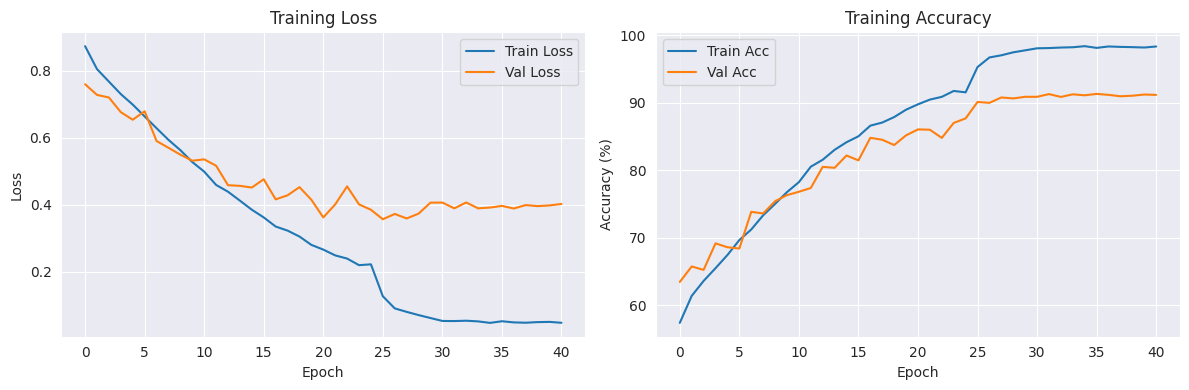

Test Accuracy: 93.77%


In [4]:

# Create model
num_classes = len(train_dataset.label_to_idx)
model = RoofTextureClassifier(num_classes).to(device)

# Calculate class weights
unique_labels = list(train_dataset.label_to_idx.keys())
y_indices = [train_dataset.label_to_idx[label] for label in y_train]
class_weights = compute_class_weight('balanced', classes=np.unique(y_indices), y=y_indices)
class_weights = torch.FloatTensor(class_weights).to(device)

# Train model
trainer = Trainer(model, device, config)
history = trainer.train(train_loader, val_loader, class_weights)

# Plot results
plot_training_history(history)

# Test evaluation
model.load_state_dict(torch.load(config.MODEL_SAVE_PATH)['model_state_dict'])
test_loss, test_acc = trainer.validate(test_loader, nn.CrossEntropyLoss())
print(f"Test Accuracy: {test_acc:.2f}%")


In [ ]:
num_classes = len(train_dataset.label_to_idx)
print(num_classes)
